# GAN-based Anomaly Detection for Early Warning Systems

This notebook implements the optimization direction suggested in `EarlyWarningSystemPoliMI.ipynb`: use a GAN to learn the distribution of **normal market conditions**, then flag observations that are not compatible with that learned normality.

The logic is intentionally aligned with the existing MVG and Autoencoder models:

1. Train on **normal observations only**.
2. Score each cross-validation and test observation.
3. Choose a threshold `epsilon` on the cross-validation set.
4. Evaluate on the held-out test set with precision, recall, F1, ROC-AUC, confusion matrix, and score plots.

GAN flow:

```text
Noise vector z
      ↓
Generator
      ↓
Synthetic normal market sample
      ↓
Discriminator
      ↓
Probability of being real normal data
```

Two anomaly scores are implemented:

- **Discriminator realism score**: low `D(x)` means the point does not look like real normal data.
- **Reconstruction-based GAN score**: find a latent vector `z*` such that `G(z*)` reconstructs `x`, then use the reconstruction error.


In [12]:
# Setup: imports and reproducibility
from __future__ import annotations

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import multivariate_normal
from sklearn.metrics import (
    auc,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = [10, 6]

%config InlineBackend.figure_format = 'retina'

print(f"Using device: {device}")

Using device: cpu


## 1. Create a controlled market-like anomaly detection problem

We start with the same teaching setup used in the original notebook: normal observations are common and structured; anomalies are rare and come from a different distribution.

The GAN only sees the normal training data. The cross-validation and test sets contain both normal and anomalous observations so we can tune and evaluate the threshold.

Training set: (1800, 2) normal only
Cross-validation set: (640, 2), contamination=0.062
Test set: (640, 2), contamination=0.062


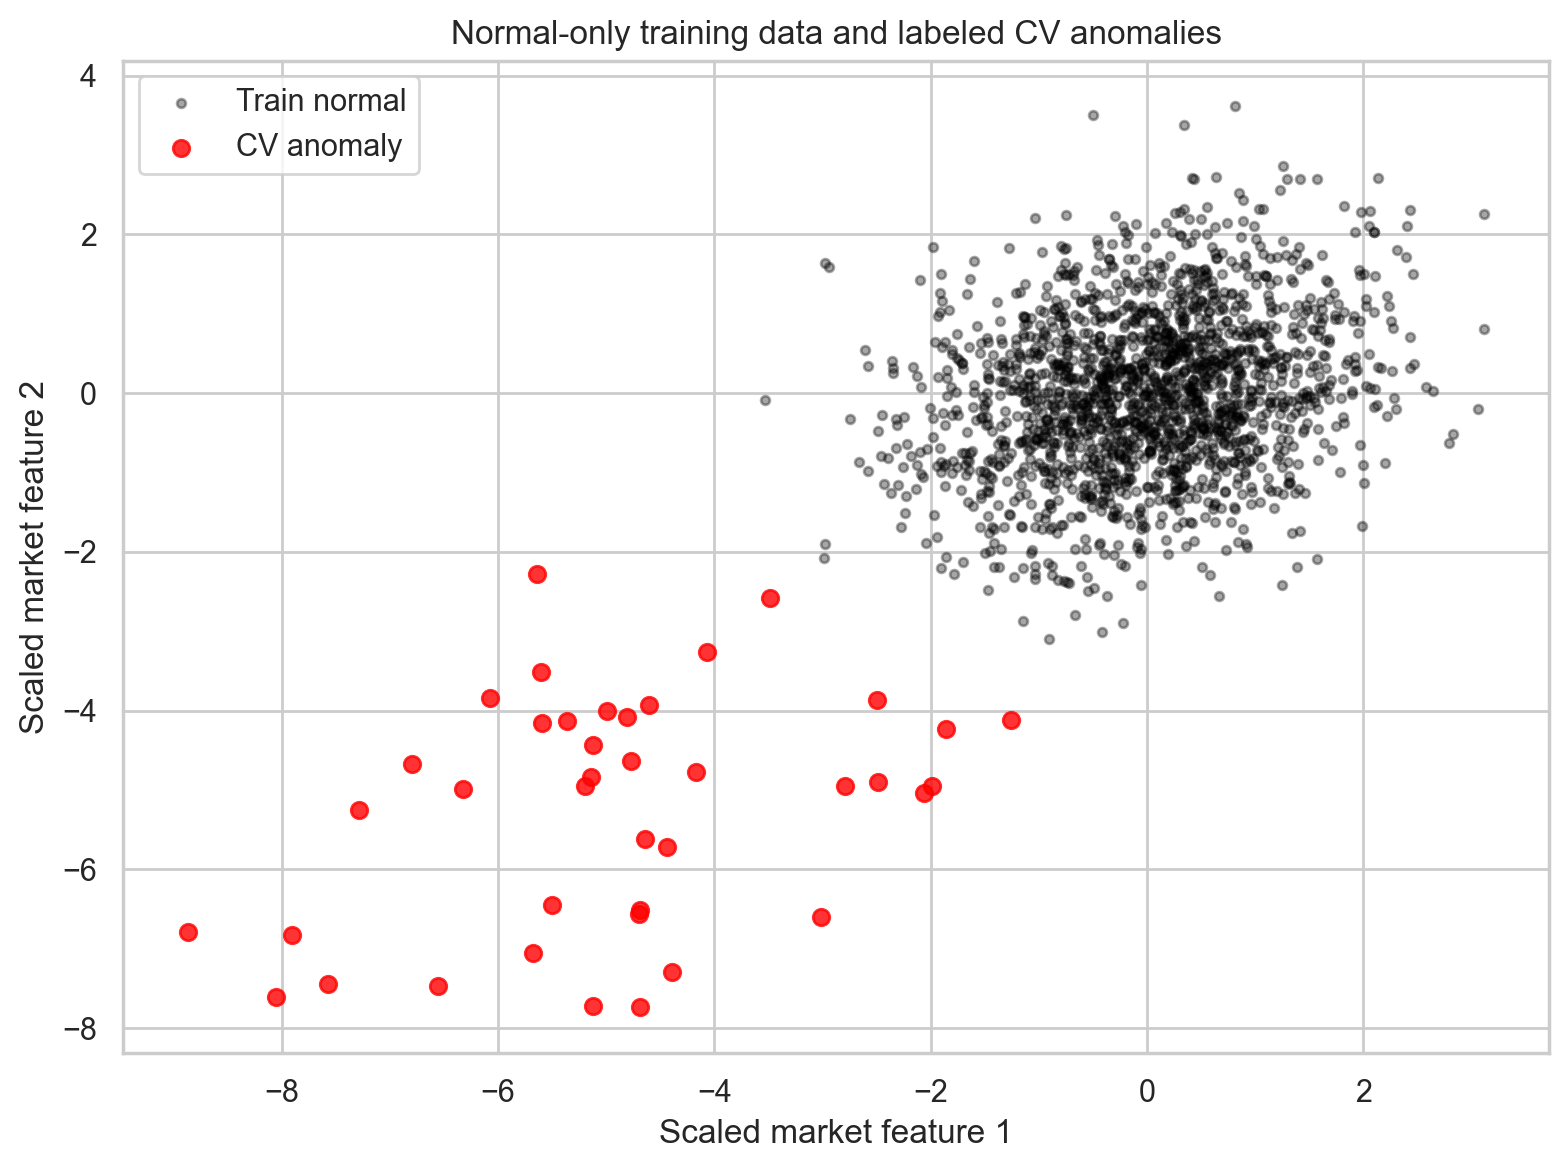

In [13]:
# Synthetic market sample: normal observations plus rare anomalies
mu_normal = np.array([1.0, 1.0])
sigma_normal = np.array([[1.7, 0.5], [0.5, 1.9]])
n_normal = 3000

mu_anomaly = np.array([-5.0, -6.0])
sigma_anomaly = np.array([[4.5, 0.95], [0.95, 3.5]])
n_anomaly = 80

normal_samples = np.random.multivariate_normal(mu_normal, sigma_normal, n_normal)
anomaly_samples = np.random.multivariate_normal(mu_anomaly, sigma_anomaly, n_anomaly)

# Train on normal observations only; CV/test contain normal + anomaly labels.
X_train_raw = normal_samples[:1800]
X_cross_val_raw = np.vstack([normal_samples[1800:2400], anomaly_samples[:40]])
y_cross_val = np.hstack([np.zeros(600), np.ones(40)]).astype(int)
X_test_raw = np.vstack([normal_samples[2400:], anomaly_samples[40:]])
y_test = np.hstack([np.zeros(600), np.ones(40)]).astype(int)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_cross_val = scaler.transform(X_cross_val_raw)
X_test = scaler.transform(X_test_raw)

print(f"Training set: {X_train.shape} normal only")
print(f"Cross-validation set: {X_cross_val.shape}, contamination={y_cross_val.mean():.3f}")
print(f"Test set: {X_test.shape}, contamination={y_test.mean():.3f}")

plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], s=10, c="black", alpha=0.35, label="Train normal")
plt.scatter(X_cross_val[y_cross_val == 1, 0], X_cross_val[y_cross_val == 1, 1],
            s=35, c="red", alpha=0.8, label="CV anomaly")
plt.xlabel("Scaled market feature 1")
plt.ylabel("Scaled market feature 2")
plt.title("Normal-only training data and labeled CV anomalies")
plt.legend()
plt.tight_layout()
plt.show()

## 2. Define the GAN

The discriminator returns a **logit**, not a probability. During training we use `BCEWithLogitsLoss`, which is numerically more stable than applying a sigmoid first. During scoring we convert logits to probabilities with `torch.sigmoid`.

The generator maps a latent noise vector `z` into a synthetic normal market sample.

In [14]:
# GAN architecture
input_dim = X_train.shape[1]
latent_dim = 8
hidden_dim = 32
batch_size = 128

train_tensor = torch.tensor(X_train, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True)

class Generator(nn.Module):
    def __init__(self, latent_dim: int, output_dim: int, hidden_dim: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

G = Generator(latent_dim, input_dim, hidden_dim).to(device)
D = Discriminator(input_dim, hidden_dim).to(device)

criterion = nn.BCEWithLogitsLoss()
g_optimizer = optim.Adam(G.parameters(), lr=1e-3, betas=(0.5, 0.999))
d_optimizer = optim.Adam(D.parameters(), lr=1e-3, betas=(0.5, 0.999))

G, D

(Generator(
   (net): Sequential(
     (0): Linear(in_features=8, out_features=32, bias=True)
     (1): LeakyReLU(negative_slope=0.2)
     (2): Linear(in_features=32, out_features=32, bias=True)
     (3): LeakyReLU(negative_slope=0.2)
     (4): Linear(in_features=32, out_features=2, bias=True)
   )
 ),
 Discriminator(
   (net): Sequential(
     (0): Linear(in_features=2, out_features=32, bias=True)
     (1): LeakyReLU(negative_slope=0.2)
     (2): Dropout(p=0.1, inplace=False)
     (3): Linear(in_features=32, out_features=32, bias=True)
     (4): LeakyReLU(negative_slope=0.2)
     (5): Dropout(p=0.1, inplace=False)
     (6): Linear(in_features=32, out_features=1, bias=True)
   )
 ))

## 3. Train on normal market samples only

The discriminator sees:

- real normal observations from the training set
- generated normal-like observations from the generator

The generator learns to produce samples that the discriminator classifies as real normal data.

Epoch 001 | D loss=1.3512 | G loss=0.6251
Epoch 050 | D loss=1.3857 | G loss=0.7038
Epoch 100 | D loss=1.3855 | G loss=0.6964
Epoch 150 | D loss=1.3852 | G loss=0.6894
Epoch 200 | D loss=1.3915 | G loss=0.6907
Epoch 250 | D loss=1.3838 | G loss=0.7050
Epoch 300 | D loss=1.3855 | G loss=0.6910


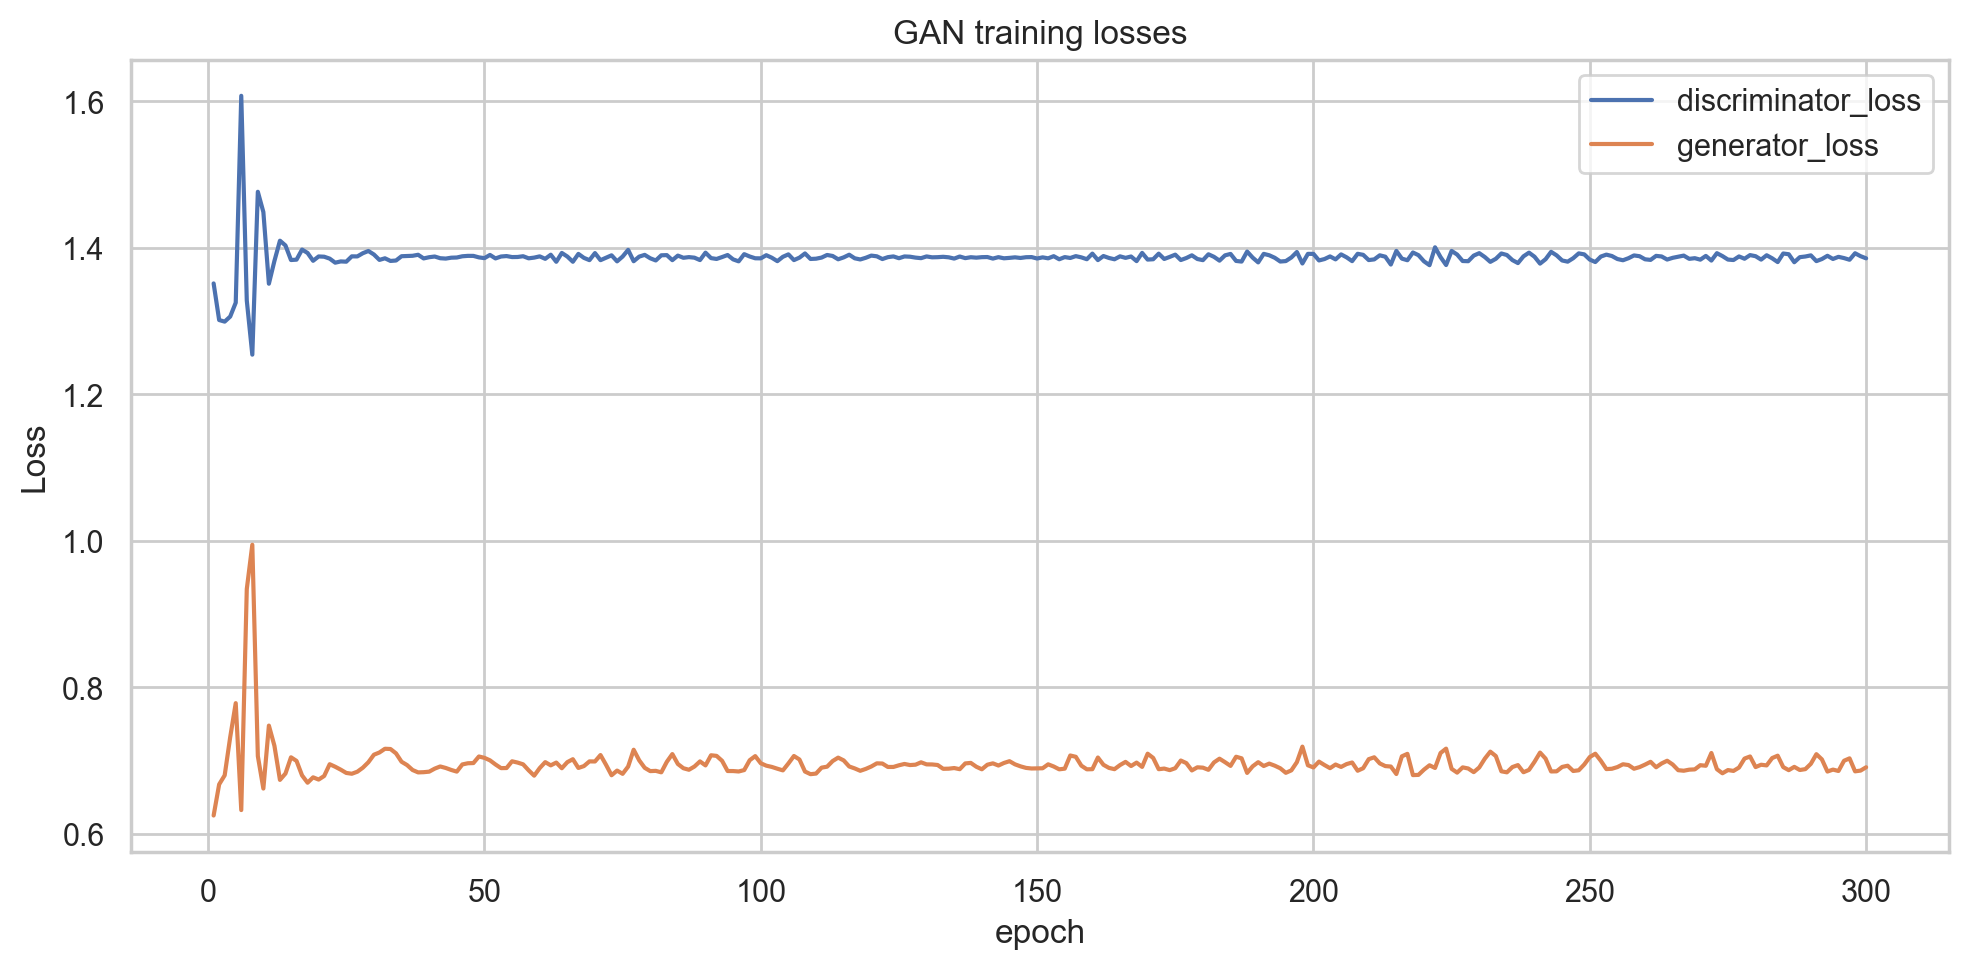

In [15]:
def train_gan(generator, discriminator, loader, epochs=300, print_every=50):
    history = []
    generator.train()
    discriminator.train()

    for epoch in range(1, epochs + 1):
        epoch_d_loss = 0.0
        epoch_g_loss = 0.0

        for (real_batch,) in loader:
            real_batch = real_batch.to(device)
            current_batch_size = real_batch.size(0)

            real_labels = torch.ones(current_batch_size, device=device)
            fake_labels = torch.zeros(current_batch_size, device=device)

            # 1. Train discriminator: real normal samples should be real, generated samples should be fake.
            z = torch.randn(current_batch_size, latent_dim, device=device)
            fake_batch = generator(z).detach()

            d_optimizer.zero_grad()
            real_logits = discriminator(real_batch)
            fake_logits = discriminator(fake_batch)
            d_loss = criterion(real_logits, real_labels) + criterion(fake_logits, fake_labels)
            d_loss.backward()
            d_optimizer.step()

            # 2. Train generator: generated samples should look real to the discriminator.
            z = torch.randn(current_batch_size, latent_dim, device=device)
            g_optimizer.zero_grad()
            generated_batch = generator(z)
            generated_logits = discriminator(generated_batch)
            g_loss = criterion(generated_logits, real_labels)
            g_loss.backward()
            g_optimizer.step()

            epoch_d_loss += d_loss.item()
            epoch_g_loss += g_loss.item()

        avg_d_loss = epoch_d_loss / len(loader)
        avg_g_loss = epoch_g_loss / len(loader)
        history.append({"epoch": epoch, "discriminator_loss": avg_d_loss, "generator_loss": avg_g_loss})

        if epoch == 1 or epoch % print_every == 0:
            print(f"Epoch {epoch:03d} | D loss={avg_d_loss:.4f} | G loss={avg_g_loss:.4f}")

    return pd.DataFrame(history)

history = train_gan(G, D, train_loader, epochs=300, print_every=50)

history.plot(x="epoch", y=["discriminator_loss", "generator_loss"], figsize=(10, 5))
plt.title("GAN training losses")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

## 4. Score anomalies with discriminator realism

The discriminator realism score is:

$$
D_{prob}(x) = P(\text{real normal data} \mid x)
$$

A point is anomalous when this probability is too low:

$$
\text{Anomaly} \Longleftrightarrow D_{prob}(x) < \varepsilon
$$

To keep the evaluation logic identical to the original notebook, we select `epsilon` on the cross-validation set by maximizing F1.

In [16]:
def discriminator_realism_score(discriminator, X):
    discriminator.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32, device=device)
    with torch.no_grad():
        logits = discriminator(X_tensor)
        probabilities = torch.sigmoid(logits).cpu().numpy()
    return probabilities

def choose_low_score_threshold(y_true, normality_score, n_grid=1000):
    """Low score means more anomalous. Predict anomaly when score < epsilon."""
    thresholds = np.linspace(normality_score.min(), normality_score.max(), n_grid)
    best = {"epsilon": thresholds[0], "f1": -1.0, "precision": 0.0, "recall": 0.0}

    for epsilon in thresholds:
        pred = (normality_score < epsilon).astype(int)
        precision = precision_score(y_true, pred, zero_division=0)
        recall = recall_score(y_true, pred, zero_division=0)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best["f1"]:
            best = {"epsilon": epsilon, "f1": f1, "precision": precision, "recall": recall}

    return best

cv_realism = discriminator_realism_score(D, X_cross_val)
test_realism = discriminator_realism_score(D, X_test)

realism_threshold = choose_low_score_threshold(y_cross_val, cv_realism)
y_pred_realism = (test_realism < realism_threshold["epsilon"]).astype(int)

realism_threshold

{'epsilon': np.float32(0.55743814),
 'f1': 0.11487481590574374,
 'precision': 0.06103286384976526,
 'recall': 0.975}

## 5. Score anomalies with GAN reconstruction

A plain GAN has no encoder, so we cannot directly map an input `x` into a latent vector. For reconstruction scoring, we search for the latent vector `z*` whose generated sample is closest to `x`:

$$
z^* = \arg\min_z \|x - G(z)\|^2
$$

Then the anomaly score is the reconstruction error:

$$
\text{Anomaly} \Longleftrightarrow \|x - G(z^*)\|^2 > \varepsilon
$$

This is slower than discriminator scoring, but it is closer to the Autoencoder logic used in the original notebook.

In [17]:
def gan_reconstruction_error(generator, X, latent_dim, steps=250, lr=0.05, batch_size=128):
    generator.eval()
    errors = []

    for start in range(0, len(X), batch_size):
        batch_np = X[start:start + batch_size]
        x = torch.tensor(batch_np, dtype=torch.float32, device=device)
        z = torch.randn(x.size(0), latent_dim, device=device, requires_grad=True)
        z_optimizer = optim.Adam([z], lr=lr)

        for _ in range(steps):
            z_optimizer.zero_grad()
            reconstructed = generator(z)
            loss = ((reconstructed - x) ** 2).mean()
            loss.backward()
            z_optimizer.step()

        with torch.no_grad():
            reconstructed = generator(z)
            batch_errors = ((reconstructed - x) ** 2).mean(dim=1).cpu().numpy()
            errors.extend(batch_errors)

    return np.array(errors)

def choose_high_score_threshold(y_true, anomaly_score, n_grid=1000):
    """High score means more anomalous. Predict anomaly when score > epsilon."""
    thresholds = np.linspace(anomaly_score.min(), anomaly_score.max(), n_grid)
    best = {"epsilon": thresholds[0], "f1": -1.0, "precision": 0.0, "recall": 0.0}

    for epsilon in thresholds:
        pred = (anomaly_score > epsilon).astype(int)
        precision = precision_score(y_true, pred, zero_division=0)
        recall = recall_score(y_true, pred, zero_division=0)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best["f1"]:
            best = {"epsilon": epsilon, "f1": f1, "precision": precision, "recall": recall}

    return best

cv_reconstruction_error = gan_reconstruction_error(G, X_cross_val, latent_dim, steps=250)
test_reconstruction_error = gan_reconstruction_error(G, X_test, latent_dim, steps=250)

reconstruction_threshold = choose_high_score_threshold(y_cross_val, cv_reconstruction_error)
y_pred_reconstruction = (test_reconstruction_error > reconstruction_threshold["epsilon"]).astype(int)

reconstruction_threshold

{'epsilon': np.float32(0.00014949843),
 'f1': 0.3333333333333333,
 'precision': 1.0,
 'recall': 0.2}

## 6. Evaluate the two GAN anomaly scores

Both scores are evaluated with the same interface used by the previous models. For ROC-AUC, the input score must increase with anomaly likelihood:

- discriminator score: `1 - D_prob(x)`
- reconstruction score: reconstruction error


GAN discriminator realism score
Precision: 0.0625
Recall:    1.0000
F1 Score:  0.1176
ROC-AUC:   0.0000


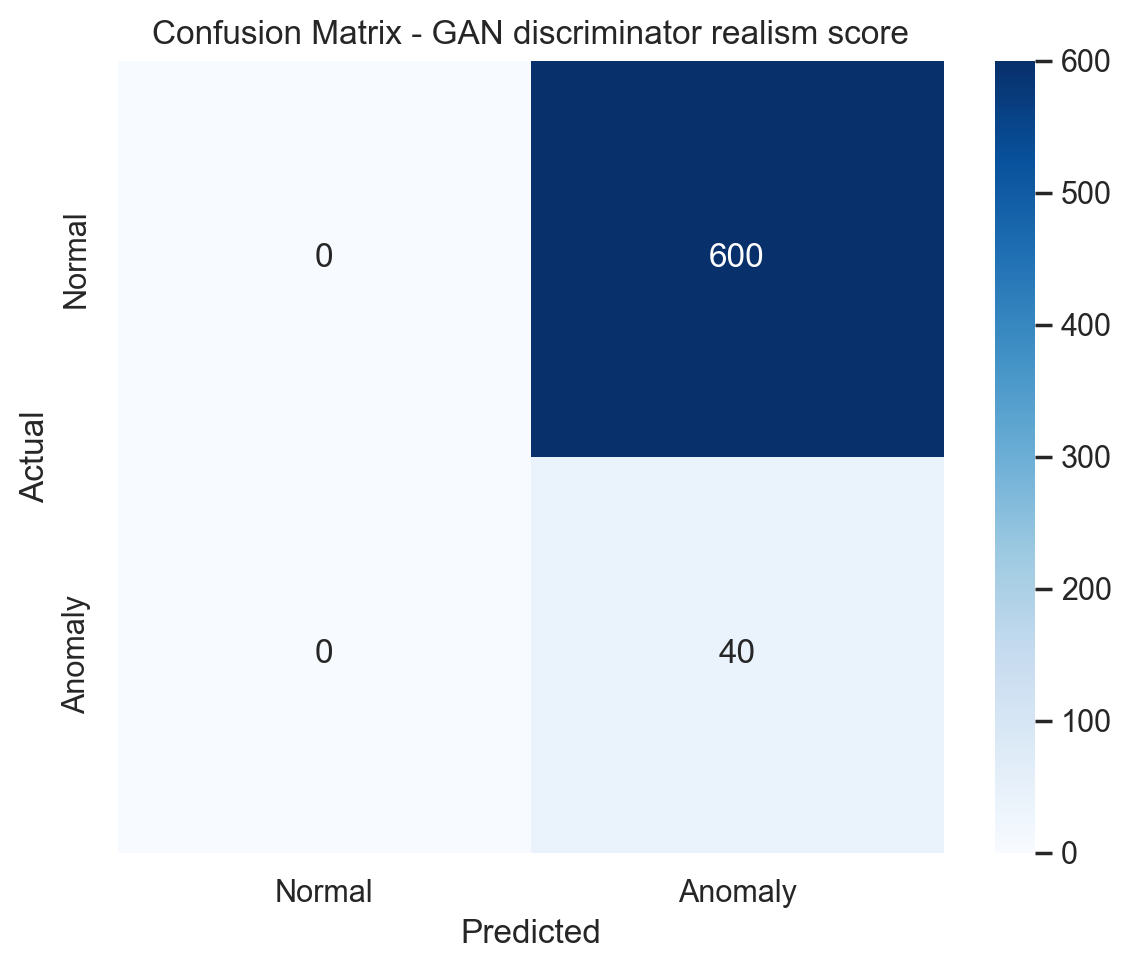

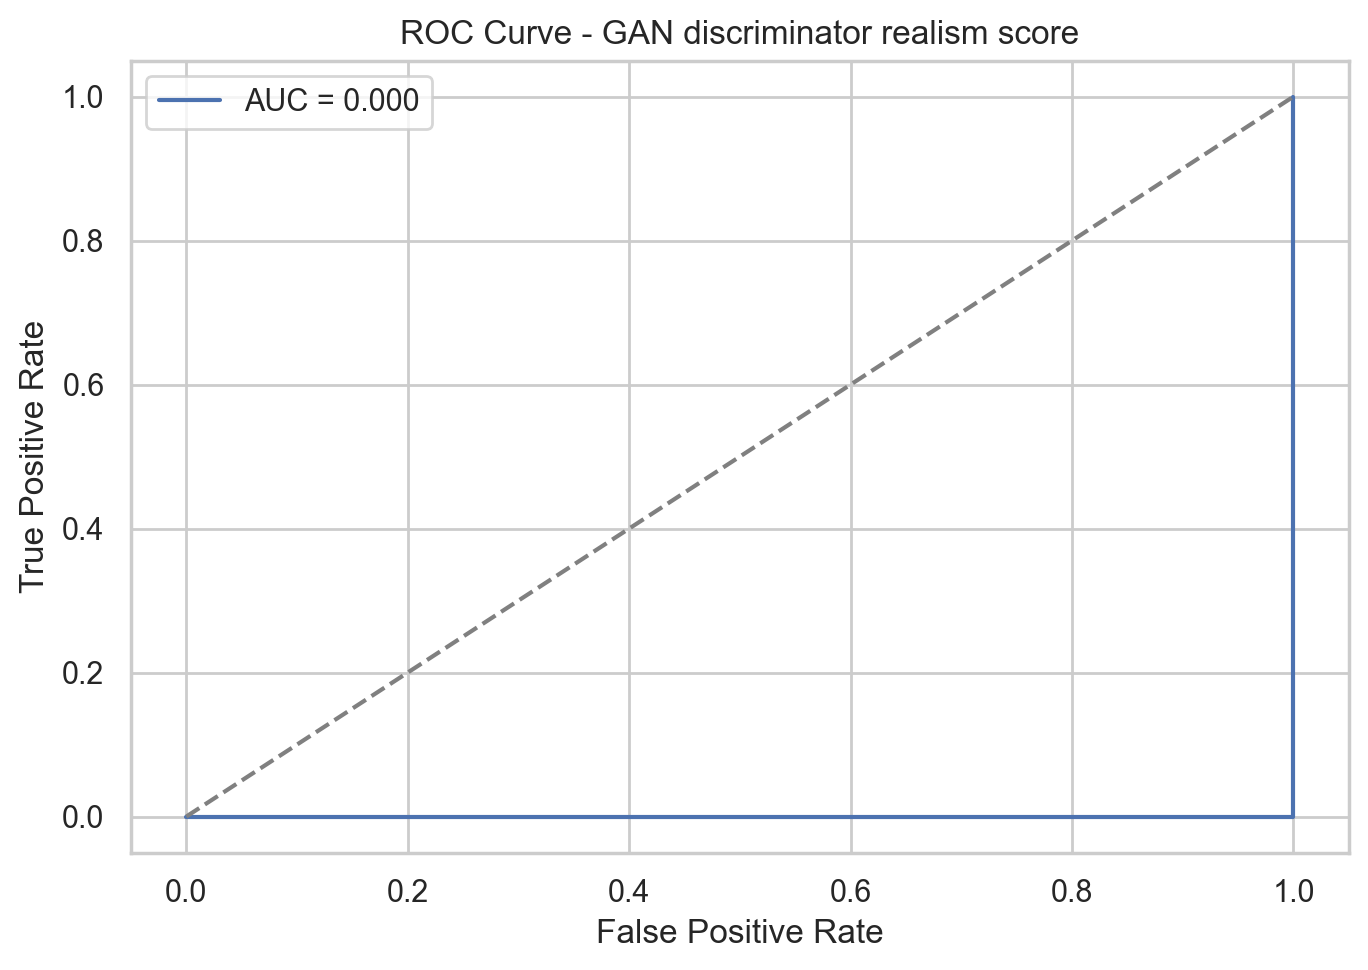


GAN reconstruction score
Precision: 1.0000
Recall:    0.1750
F1 Score:  0.2979
ROC-AUC:   0.9949


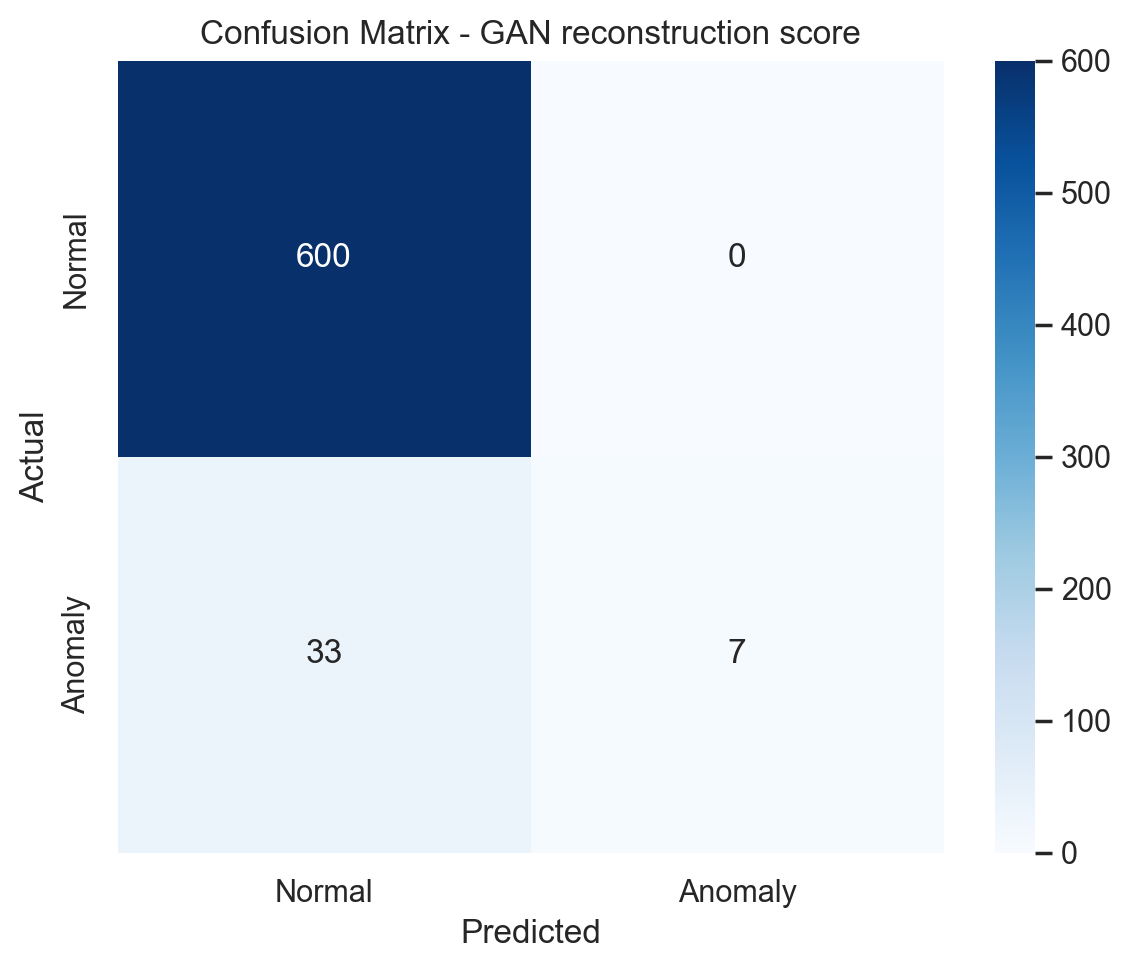

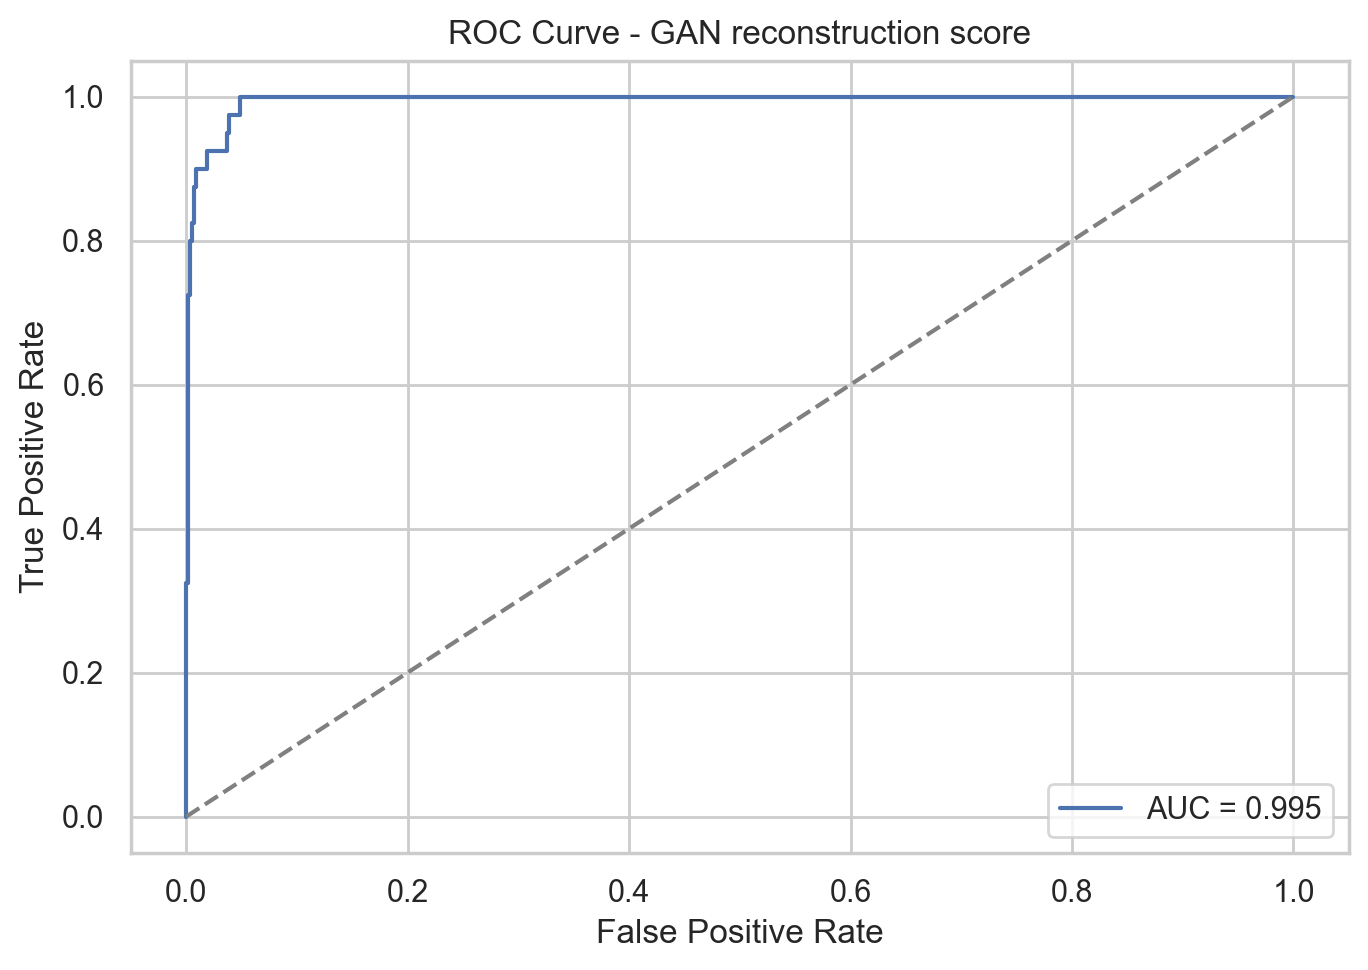

,model,precision,recall,f1,roc_auc
0,GAN discriminator realism score,0.0625,1.000,0.117647,0.000000
1,GAN reconstruction score,1.0000,0.175,0.297872,0.994875


In [18]:
def evaluate_anomaly_detector(y_true, y_pred, anomaly_score, model_name):
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_true, anomaly_score)
    roc_auc = auc(fpr, tpr)

    print(f"\n{model_name}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Anomaly"],
                yticklabels=["Normal", "Anomaly"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "model": model_name,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
    }

realism_metrics = evaluate_anomaly_detector(
    y_test,
    y_pred_realism,
    1.0 - test_realism,
    "GAN discriminator realism score",
)

reconstruction_metrics = evaluate_anomaly_detector(
    y_test,
    y_pred_reconstruction,
    test_reconstruction_error,
    "GAN reconstruction score",
)

pd.DataFrame([realism_metrics, reconstruction_metrics])

## 7. Visual diagnostics

The score distribution shows whether anomalies are separated from normal observations. The PCA-style 2D view is direct here because the synthetic data has two dimensions.

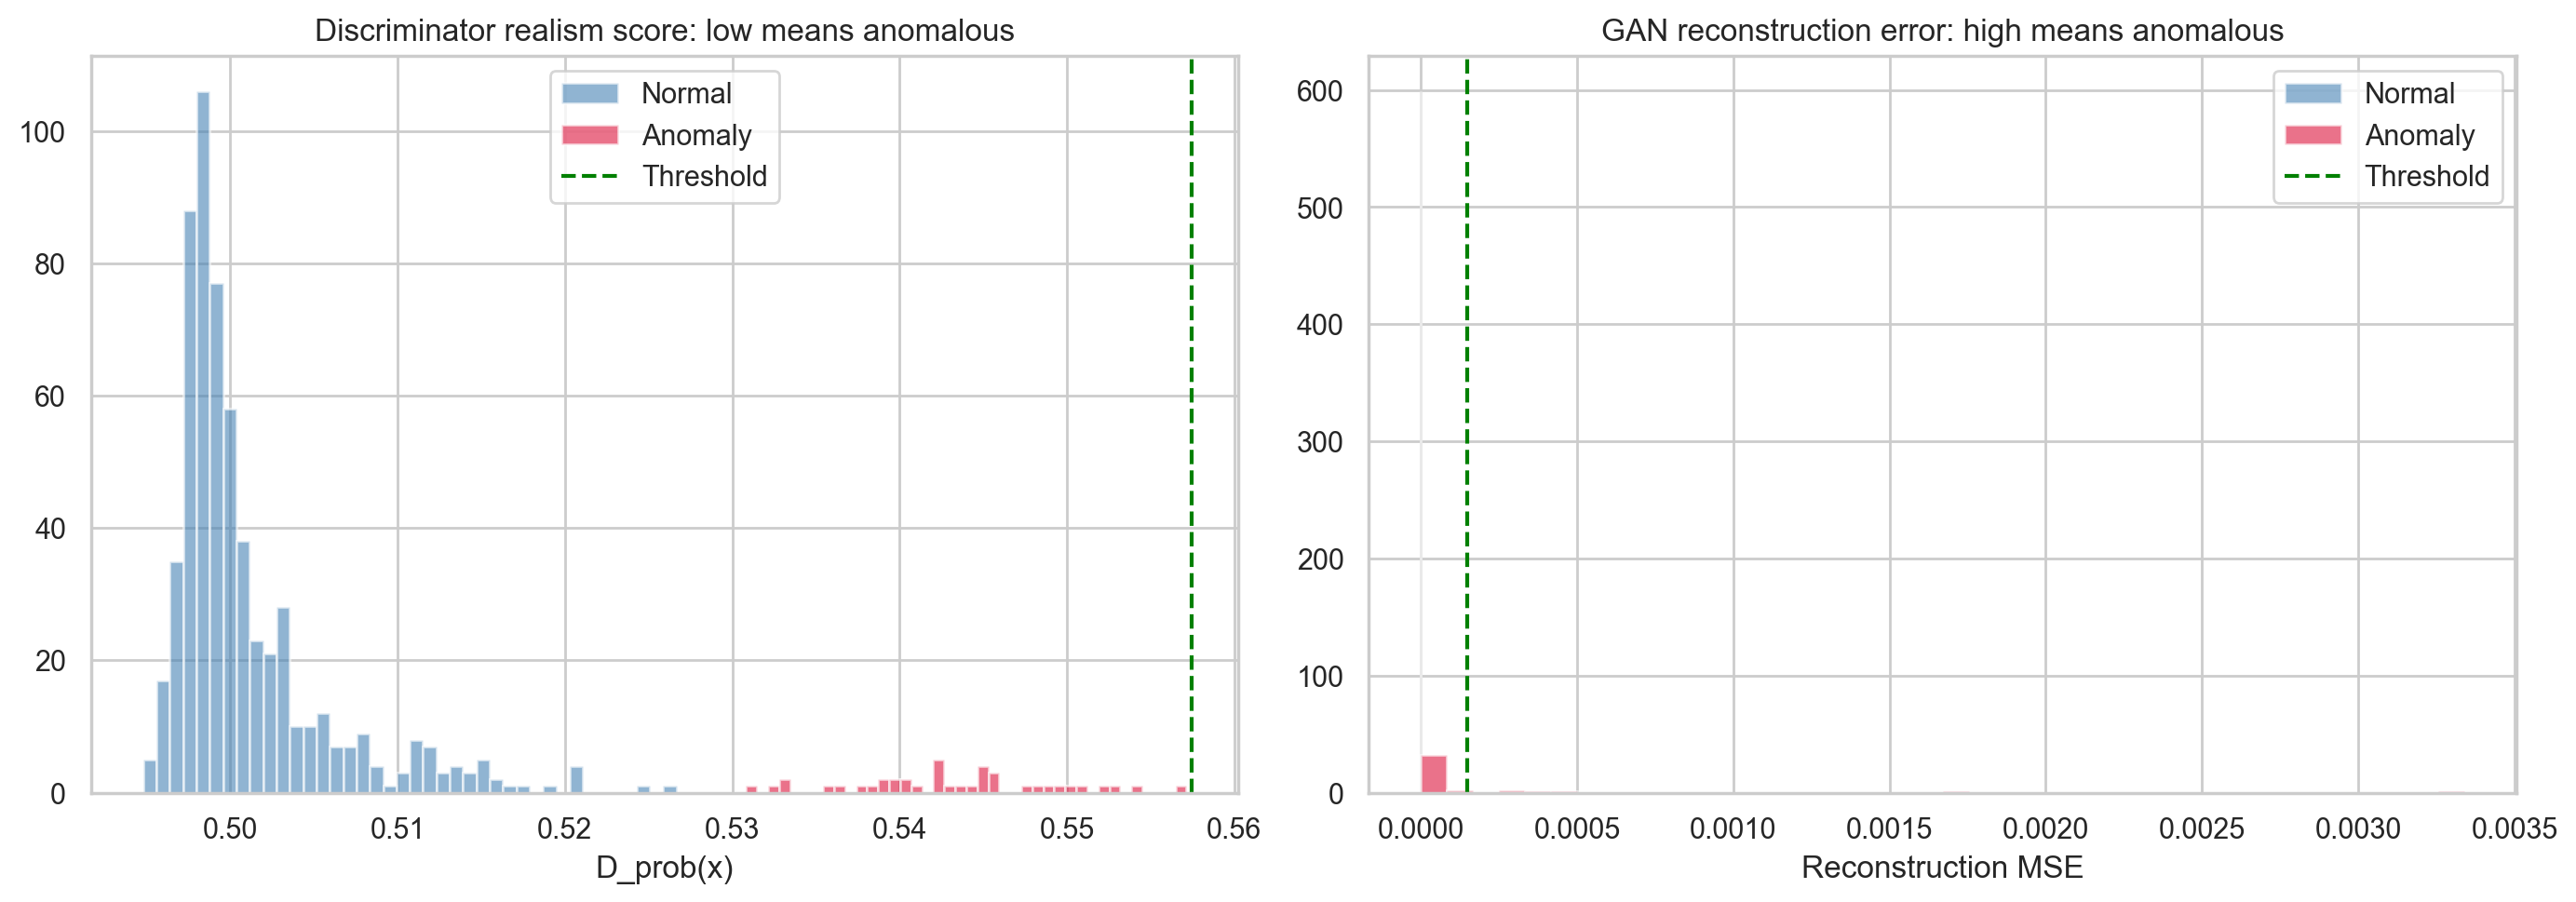

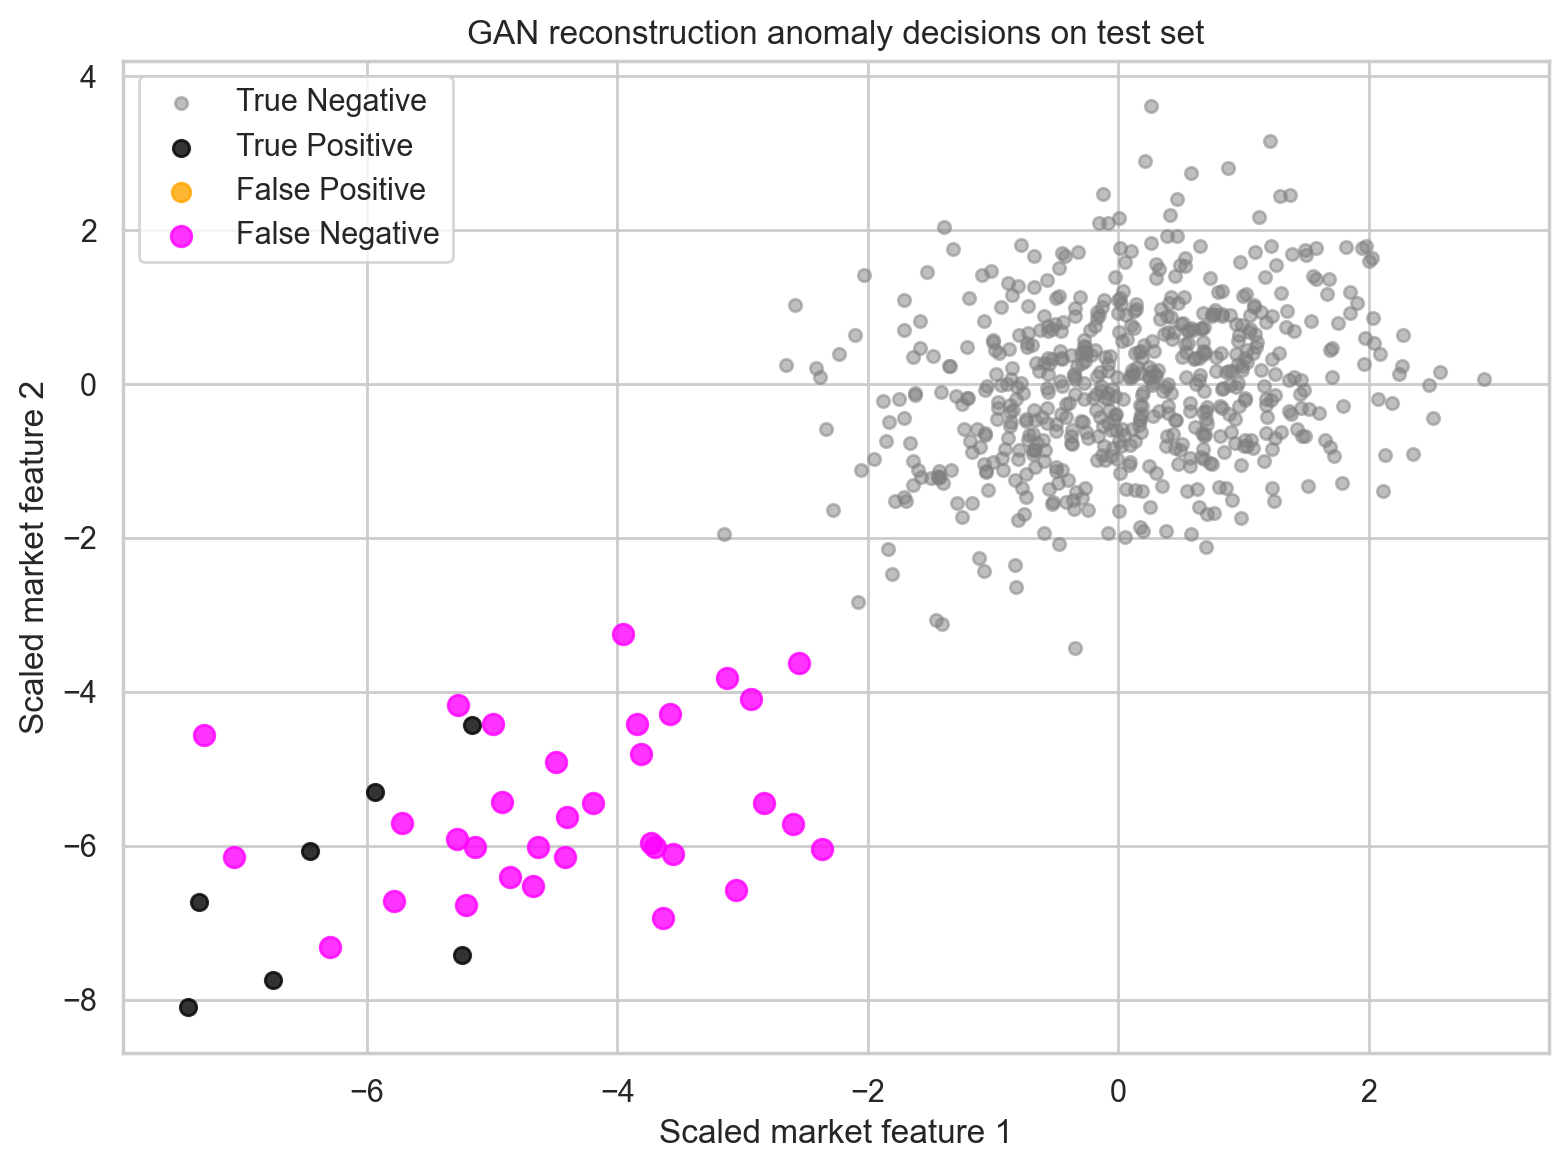

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(test_realism[y_test == 0], bins=40, alpha=0.6, label="Normal", color="steelblue")
axes[0].hist(test_realism[y_test == 1], bins=40, alpha=0.6, label="Anomaly", color="crimson")
axes[0].axvline(realism_threshold["epsilon"], color="green", linestyle="--", label="Threshold")
axes[0].set_title("Discriminator realism score: low means anomalous")
axes[0].set_xlabel("D_prob(x)")
axes[0].legend()

axes[1].hist(test_reconstruction_error[y_test == 0], bins=40, alpha=0.6, label="Normal", color="steelblue")
axes[1].hist(test_reconstruction_error[y_test == 1], bins=40, alpha=0.6, label="Anomaly", color="crimson")
axes[1].axvline(reconstruction_threshold["epsilon"], color="green", linestyle="--", label="Threshold")
axes[1].set_title("GAN reconstruction error: high means anomalous")
axes[1].set_xlabel("Reconstruction MSE")
axes[1].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X_test[(y_test == 0) & (y_pred_reconstruction == 0), 0],
            X_test[(y_test == 0) & (y_pred_reconstruction == 0), 1],
            c="gray", s=20, alpha=0.5, label="True Negative")
plt.scatter(X_test[(y_test == 1) & (y_pred_reconstruction == 1), 0],
            X_test[(y_test == 1) & (y_pred_reconstruction == 1), 1],
            c="black", s=35, alpha=0.8, label="True Positive")
plt.scatter(X_test[(y_test == 0) & (y_pred_reconstruction == 1), 0],
            X_test[(y_test == 0) & (y_pred_reconstruction == 1), 1],
            c="orange", s=45, alpha=0.8, label="False Positive")
plt.scatter(X_test[(y_test == 1) & (y_pred_reconstruction == 0), 0],
            X_test[(y_test == 1) & (y_pred_reconstruction == 0), 1],
            c="magenta", s=55, alpha=0.8, label="False Negative")
plt.xlabel("Scaled market feature 1")
plt.ylabel("Scaled market feature 2")
plt.title("GAN reconstruction anomaly decisions on test set")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Notes for adapting this to the real EWS data

To use this notebook with the real market data from `EarlyWarningSystemPoliMI.ipynb`, replace the synthetic data cell with the same prepared arrays used by the existing models:

- `X_train_scaled` or `X_train`: normal-only training observations
- `X_cv_scaled` or `X_cross_val`: cross-validation observations
- `y_cross_val`: cross-validation labels
- `X_test_scaled` or `X_test`: test observations
- `y_test`: test labels

Keep the rest of the logic unchanged:

1. Fit the GAN on normal training data only.
2. Compute discriminator realism and/or reconstruction scores on CV and test sets.
3. Tune the threshold on the CV set.
4. Compare against MVG, Isolation Forest, LOF, GMM, and Autoencoder on the same test set.

Practical warning: GANs are often unstable on tabular financial data. Treat this as a research direction and benchmark it against simpler baselines before using it as an Early Warning System component.